# FG-Repeat Sliding Dynamics iMSM Tutorial (Figure 6)

This notebook demonstrates how to construct and analyze an **interaction Markov State Model (iMSM)** for multi-site FG-repeat sliding dynamics on the surface of Karyopherin Kap95, replicating the analysis from Figure 6 of the manuscript.

### Physical Representation & Method Overview
iMSMs resolve the multi-site sliding of disordered FG motifs across transport receptor surfaces by discretizing time-averaged interaction distributions around a focal motif:
1. **Partitioning the System**: The system is partitioned into interacting components $\mathcal{C} = \{c_1, \ldots, c_{861}\}$ (the 861 C $\alpha$ residues across Kap95 HEAT repeats 1–21) and a focal entity $f$ (the center of mass of the interacting FSFG core motif, `fgC88_91_com`).
2. **Interaction Trajectory $I(t)$**: All-atom MD trajectories are converted into an interaction trajectory $I(t)$ recording spatial contacts between the focal FG motif and Kap95 surface residues within contact distance `max_surface_dist = 1.0` nm, retaining up to `interaction_capacity = 5` closest residue contacts per frame.
3. **Windowed Interaction Histograms $H$**: $I(t)$ is partitioned into consecutive time windows of duration $\tau = 500$ frames (480 ns). The interaction statistics in each window are summarized into an interaction histogram $H$, normalized by the fixed reference `interaction_capacity`. This allows the representation to distinguish strongly engaged sliding pockets from weakly engaged or unbound states.
4. **Unsupervised Clustering**: Histograms are clustered into a reduced set of $k = 5$ recurring interaction states $\mathcal{S} = \{s_1, \ldots, s_5\}$ corresponding to discrete sliding pockets across the inner and outer surfaces of Kap95.
5. **Lagged Transition Matrix & 2D Spatial Network**: Transitions between states at lag time $\tau$ are recorded to estimate the transition-probability matrix $T_{ij}$. Spatial centroids are projected onto the 2D plane of Kap95, mapping the transition flux network colored by HEAT repeat residue index (Panel B) and interaction fraction (Panel D).


## 0. Set Paths
Define paths to the topology, trajectory files, and the iMSM checkpoint directory.

In [1]:
import os
from pathlib import Path

# Set repository root
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()

TOP_PATH = str(REPO_ROOT / "data/nup_sims/fsfgx2/output_from_0_nowat.dms.pdb")
TRAJ_PATHS = [
    str(REPO_ROOT / f"data/nup_sims/fsfgx2/output_from_{start}_to_{end}_nowat_unwarped.dcd")
    for start, end in [(0, 2499), (2500, 4999), (5000, 7499), (7500, 9999), (10000, 12499)]
] + [str(REPO_ROOT / "data/nup_sims/fsfgx2/output_from_12500_nowat_unwarped.dcd")]

CHECKPOINT_BASE_PATH = str(REPO_ROOT / "data/nup_sims/fsfgx2/imsm/")
FOCAL_CHECKPOINT_PATH = str(REPO_ROOT / "data/nup_sims/fsfgx2/imsm/fgC88_91_com")
PLOTS_OUTPUT_DIR = str(REPO_ROOT / "plots/figure_6")

## 1. Import Required Libraries
All imports are centralized in this dedicated import cell.

In [2]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Ensure repository root and figure_scripts are on sys.path
repo_root = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
for path in [str(repo_root), str(repo_root / "figure_scripts")]:
    if path not in sys.path:
        sys.path.insert(0, path)

from figure_fg_sliding_helpers import (
    setup_fg_sliding_data,
    setup_fg_sliding_params,
    run_fg_sliding_imsm,
    plot_fg_spatial_network,
)

## 2. Setup Data and iMSM Physical Representation Parameters
Extracts trajectory slices for Kap95 and the focal FG-repeat motif (`fgC88_91_com`), and defines the iMSM representation parameters matching Figure 6.


In [ ]:
# Extract trajectory slices and create iMSM inputs for focal entity fgC88_91_com
data = setup_fg_sliding_data(
    traj_paths=TRAJ_PATHS,
    top_path=TOP_PATH,
    imsm_checkpoint_base_path=CHECKPOINT_BASE_PATH,
    stride=1,
    first_frame=None,
    last_frame=None,
)

# Configure iMSM sliding parameters matching Figure 6
params = setup_fg_sliding_params(
    window_size=500,          # Window duration tau (500 frames * 0.96 ns = 480 ns)
    interaction_capacity=5,   # Fixed reference interaction capacity for normalizing histograms H
    max_surface_dist=1.0,     # Contact definition cutoff distance in nm
    n_clusters=5,             # Number of recurring interaction states (sliding mesostates)
    merge_cluster_threshold=0.1,
    tm_prior=0.01,            # Transition matrix prior
    start_stage=1,
    end_stage=5,
    ns_per_frame_base=0.96,
    stride=1,
)


## 3. Run iMSM Pipeline
Executes interaction trajectory generation ($I(t)$), histogram embedding ($H$), unsupervised clustering ($\mathcal{S}$), and transition matrix estimation ($T_{ij}$).
*Note: If checkpoints already exist in `data/nup_sims/fsfgx2/imsm/fgC88_91_com`, you can skip directly to Section 4.*


In [ ]:
# Execute iMSM for all configured runs (or use existing precomputed checkpoints)
run_fg_sliding_imsm(
    imsm_runs=data["imsm_runs"],
    params=params,
    top_path=TOP_PATH,
    kap_n_ca=861,
    heat5_range=(175, 195),
    heat6_range=(218, 232),
)

## 4. Visualize Spatial Network of Markov States (Figure 6 Panel B)
Projects Markov state centroids onto the 2D plane of Kap95, colored by HEAT repeat residue index, displaying the kinetic network of transition rates between recurring sliding states.



Markov State Analysis (Focal Bead fgC88_91_com, Native Similarity Thresh: 0.75):
Total Interacting %: State 0: 55.3%, State 1: 96.1%, State 2: 33.4%, State 3: 85.2%, State 4: 55.4%
Cluster Cosine Similarities: State 0: 0.133, State 1: 0.432, State 2: 0.140, State 3: 0.203, State 4: 0.127
Matched native-like states: []

--- Native PDB Conformation Composition ---
  kapC185     :  20.00%
  kapC144     :  20.00%
  kapC143     :  20.00%
  kapC181     :  20.00%
  kapC184     :  20.00%

[Auto-Align Plane] Optimal camera viewing angles for HEAT repeats plane:
  rotation_x_deg = -44.20°
  rotation_y_deg = -56.06°
  rotation_z_deg = -25.78°
  HEAT repeats plane normal: [0.5948, -0.6972, 0.4003]



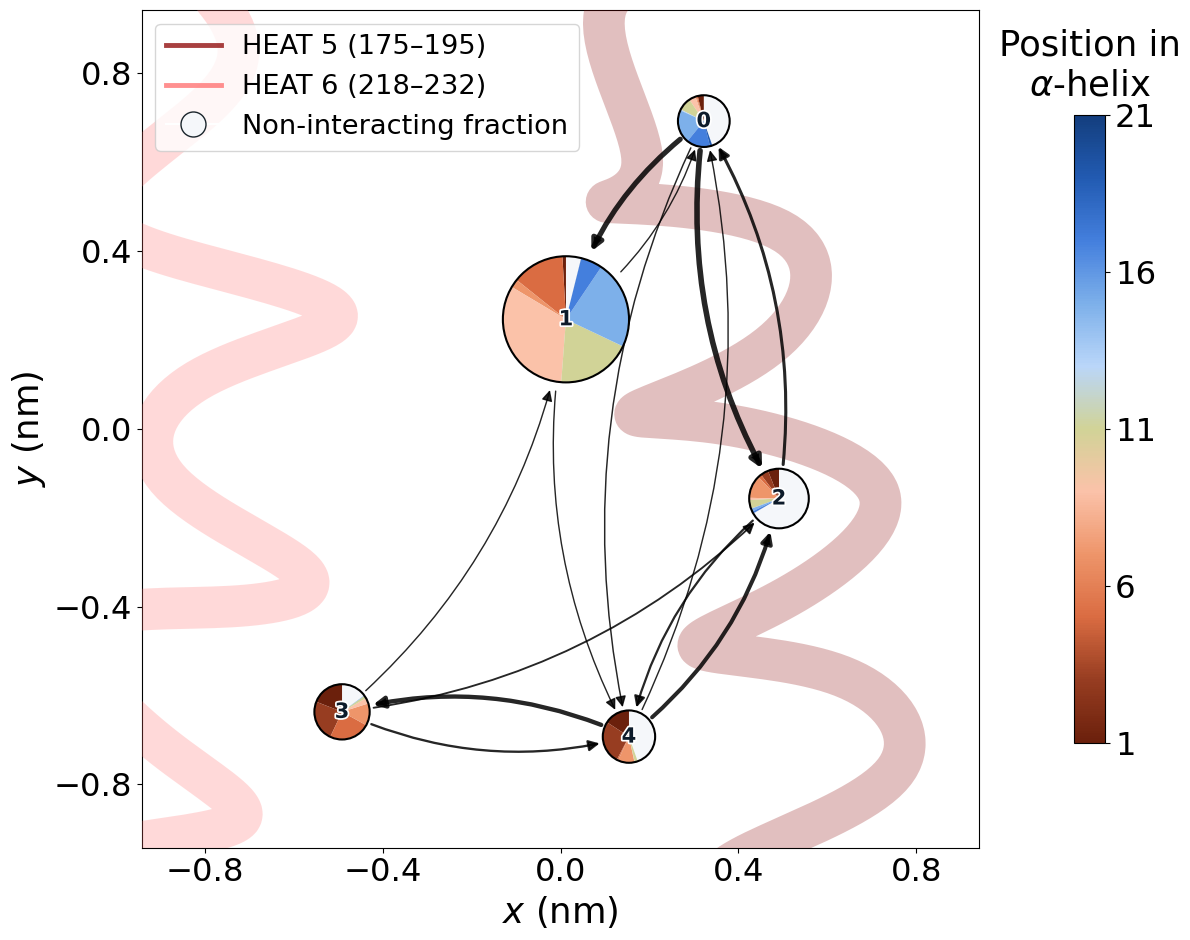

In [3]:
os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)
panel_b_path = os.path.join(PLOTS_OUTPUT_DIR, "panel_b.png")

fig_b = plot_fg_spatial_network(
    top_path=TOP_PATH,
    imsm_checkpoint_path=FOCAL_CHECKPOINT_PATH,
    output_plot_path=panel_b_path,
    top_rate_percentile=10.0,
    kap_n_ca=861,
    repeat_colors=("#78909C", "#CFD8DC"),
    zoom=True,
    state_size_factor=5.0,
    free_threshold=0.9,
    dt_ns=1000.0,
    auto_align_plane=True,
    rotation_x_deg=0.0,
    rotation_y_deg=0.0,
    rotation_z_deg=0.0,
    heat5_range=(175, 195),
    heat6_range=(218, 232),
    focal_fg_alphacarbon=(88, 91),
    native_pdb_path=TOP_PATH,
    interaction_capacity=5,
    max_surface_dist=1.0,
    native_similarity_threshold=0.75,
    top_n_print=10,
    title="",
    show_full_kap=False,
    heat_ribbon_width=30,
    heat_ribbon_alpha=0.25,
    state_color_mode="residue_index",
    arrow_color="black",
    show_rate_colorbar=False,
    show_residue_colorbar=True,
    diverging_palette=(
        "#6B200C",
        "#973D21",
        "#DA6C42",
        "#EE956A",
        "#FBC2A9",
        "#D1D397",
        "#BAD6F9",
        "#7DB0EA",
        "#447FDD",
        "#225BB2",
        "#133E7E",
    ),
    residue_color_range=(1, 21),
)
plt.show()

## 5. Visualize Spatial Network by Interaction Fraction (Figure 6 Panel D)
Displays the spatial network of sliding states colored by interaction fraction / contact density, with edge thicknesses proportional to transition rates.



Markov State Analysis (Focal Bead fgC88_91_com, Native Similarity Thresh: 0.75):
Total Interacting %: State 0: 55.3%, State 1: 96.1%, State 2: 33.4%, State 3: 85.2%, State 4: 55.4%
Cluster Cosine Similarities: State 0: 0.133, State 1: 0.432, State 2: 0.140, State 3: 0.203, State 4: 0.127
Matched native-like states: []

--- Native PDB Conformation Composition ---
  kapC185     :  20.00%
  kapC144     :  20.00%
  kapC143     :  20.00%
  kapC181     :  20.00%
  kapC184     :  20.00%

[Auto-Align Plane] Optimal camera viewing angles for HEAT repeats plane:
  rotation_x_deg = -44.20°
  rotation_y_deg = -56.06°
  rotation_z_deg = -25.78°
  HEAT repeats plane normal: [0.5948, -0.6972, 0.4003]



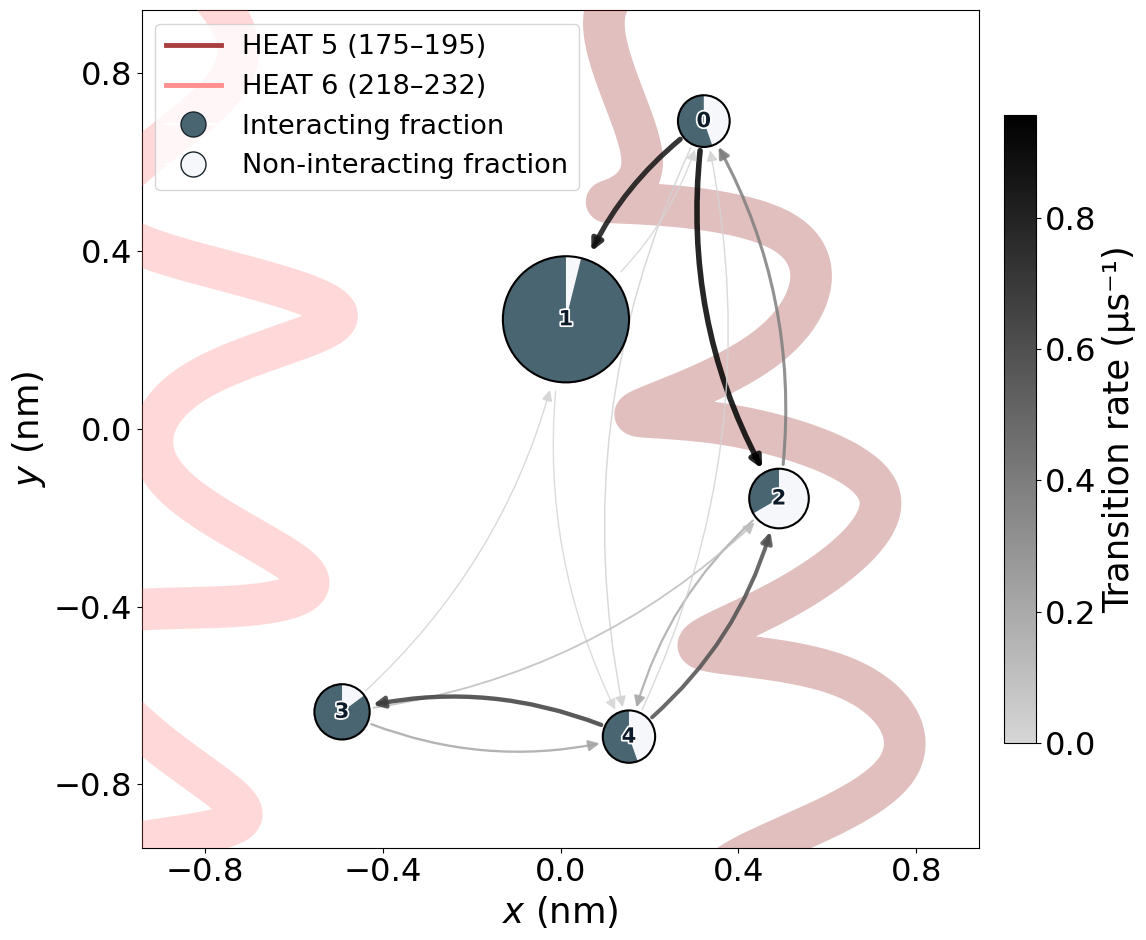

In [4]:
panel_d_path = os.path.join(PLOTS_OUTPUT_DIR, "panel_d.png")

fig_d = plot_fg_spatial_network(
    top_path=TOP_PATH,
    imsm_checkpoint_path=FOCAL_CHECKPOINT_PATH,
    output_plot_path=panel_d_path,
    top_rate_percentile=10.0,
    kap_n_ca=861,
    repeat_colors=("#78909C", "#CFD8DC"),
    zoom=True,
    state_size_factor=5.0,
    free_threshold=0.9,
    dt_ns=1000.0,
    auto_align_plane=True,
    rotation_x_deg=0.0,
    rotation_y_deg=0.0,
    rotation_z_deg=0.0,
    heat5_range=(175, 195),
    heat6_range=(218, 232),
    focal_fg_alphacarbon=(88, 91),
    native_pdb_path=TOP_PATH,
    interaction_capacity=5,
    max_surface_dist=1.0,
    native_similarity_threshold=0.75,
    top_n_print=10,
    title="",
    show_full_kap=False,
    heat_ribbon_width=30,
    heat_ribbon_alpha=0.25,
    state_color_mode="interaction_fraction",
    arrow_color=None,
    show_rate_colorbar=True,
    show_residue_colorbar=False,
    diverging_palette=(),
    residue_color_range=(1, 21),
)
plt.show()